# Group 3 · Lab A — The Vanishing Gradient Over Time (RNN vs LSTM)

In Gradient Autopsy we watched gradients vanish across *layers*. Here we watch the same thing happen
across *time* in a recurrent network, and watch an LSTM fix it.

Two halves, mirroring the diagnostic method:

1. **Symptom** - a "remember the first signal" memory task. The label depends only on the first
   timestep, so the model must carry that information across the whole sequence. As the sequence gets
   longer, a plain RNN forgets it (accuracy falls to chance) while an LSTM holds on.
2. **Diagnosis** - we directly measure the gradient of the output with respect to each input timestep.
   The plain RNN's gradient to early timesteps is effectively zero (vanished); the LSTM's is preserved.
   This is the time-axis version of the per-layer gradient heatmap.

All PyTorch, in Colab.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 1 · The memory task

Each input is a sequence of length T. Every timestep is a random value in [-1, 1] drawn from the
*same* distribution, so the first element is not special by magnitude - the model cannot cheat by
detecting a spike. The label depends only on the sign of the **first** timestep.

To get the label right, the network must carry information from step 0 all the way to the end of the
sequence. The longer the sequence, the longer that memory must survive - which is exactly what
stresses the vanishing-gradient-over-time problem.

In [2]:
def make_memory_data(n, T):
    """n sequences of length T. Every step ~ Uniform[-1,1]; label = 1 if the FIRST step > 0 else 0.
    The first element is indistinguishable by magnitude, so the model must genuinely remember it."""
    X = torch.rand(n, T, 1) * 2 - 1          # (n, T, 1), values in [-1, 1]
    y = (X[:, 0, 0] > 0).long()              # label depends ONLY on timestep 0
    return X, y

# Peek at one sequence so the task is concrete.
Xs, ys = make_memory_data(1, 20)
print("One sequence (length 20):")
print(np.round(Xs[0, :, 0].numpy(), 2))
print("First value:", round(Xs[0, 0, 0].item(), 2), "-> label:", ys.item(),
      "(1 means first value was positive)")

One sequence (length 20):
[ 0.76  0.83 -0.23  0.92 -0.22  0.2  -0.49  0.59  0.88 -0.73  0.87  0.19
  0.74  0.14  0.48 -0.14  0.77  0.15 -0.47  0.25]
First value: 0.76 -> label: 1 (1 means first value was positive)


## 2 · The models

The same classifier wrapped around either a plain RNN or an LSTM. Both read the sequence and use the
**final** hidden state to predict the label, so both must have carried the first-step information all
the way through.

For the LSTM we initialize the **forget-gate bias to 1** - a standard trick that makes the cell start
out inclined to *remember* rather than forget, which helps it learn long-range dependencies.

In [4]:
class SeqClassifier(nn.Module):
    def __init__(self, kind="rnn", hidden=48):
        super().__init__()
        rnn_cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[kind]
        self.rnn = rnn_cls(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 2)
        self.kind = kind

        # LSTM forget-gate bias = 1 (remember by default). PyTorch packs biases as
        # [input, forget, cell, output] chunks, so the forget chunk is the 2nd quarter.
        if kind == "lstm":
            for name, p in self.rnn.named_parameters():
                if "bias" in name:
                    n_h = p.shape[0] // 4
                    p.data[n_h:2*n_h].fill_(1.0)

    def forward(self, x):
        out, _ = self.rnn(x)        # out: (batch, T, hidden)
        return self.fc(out[:, -1])  # classify from the LAST timestep's hidden state

## 3 · Part 1 (symptom) - accuracy falls as the sequence grows

We train a plain RNN and an LSTM on the memory task at several sequence lengths, averaging over 3
seeds (recurrent training is noisy, so a single run can mislead). The expectation: at short lengths
both solve it; as the sequence grows, the plain RNN's accuracy falls toward chance (0.5) because it
can no longer carry the first-step information that far, while the LSTM holds up.

In [5]:
def train_eval(kind, T, seed, epochs=30, lr=3e-3):
    """Train on the memory task at sequence length T with one seed; return test accuracy."""
    torch.manual_seed(seed)
    Xtr, ytr = make_memory_data(2000, T)
    Xte, yte = make_memory_data(500, T)
    Xtr, ytr, Xte, yte = Xtr.to(device), ytr.to(device), Xte.to(device), yte.to(device)
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)

    model = SeqClassifier(kind).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # guard against exploding grads
            optimizer.step()

    model.eval()
    with torch.no_grad():
        acc = (model(Xte).argmax(1) == yte).float().mean().item()
    return acc


SEQ_LENGTHS = [10, 40, 80]
SEEDS = [0, 1, 2]
results = {"rnn": [], "lstm": []}

for T in SEQ_LENGTHS:
    for kind in ["rnn", "lstm"]:
        accs = [train_eval(kind, T, s) for s in SEEDS]
        results[kind].append((np.mean(accs), np.std(accs)))
        print(f"T={T:3d}  {kind:4s}: mean acc {np.mean(accs):.3f} +/- {np.std(accs):.3f}  "
              f"(seeds {[round(a,2) for a in accs]})")
    print()

T= 10  rnn : mean acc 0.937 +/- 0.032  (seeds [0.91, 0.98, 0.91])
T= 10  lstm: mean acc 0.995 +/- 0.002  (seeds [0.99, 1.0, 1.0])

T= 40  rnn : mean acc 0.987 +/- 0.003  (seeds [0.98, 0.99, 0.99])
T= 40  lstm: mean acc 0.993 +/- 0.001  (seeds [0.99, 0.99, 0.99])

T= 80  rnn : mean acc 0.743 +/- 0.189  (seeds [0.5, 0.96, 0.77])
T= 80  lstm: mean acc 0.847 +/- 0.211  (seeds [1.0, 0.55, 0.99])



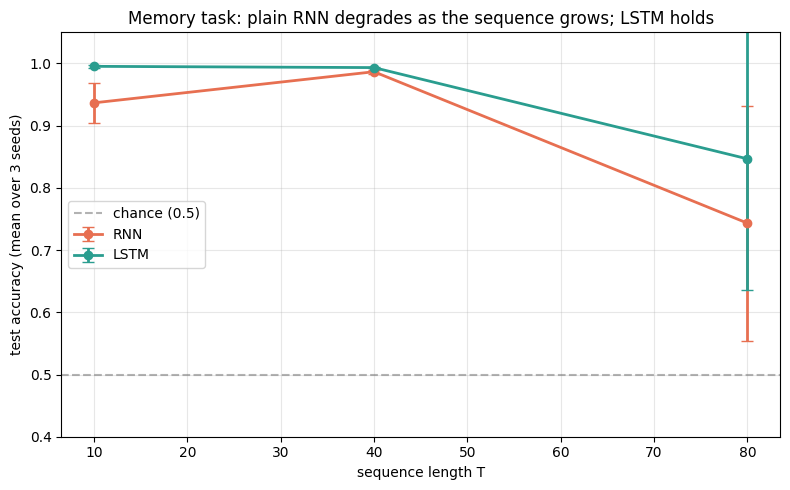

In [6]:
plt.figure(figsize=(8, 5))
for kind, color in [("rnn", "#e76f51"), ("lstm", "#2a9d8f")]:
    means = [m for m, s in results[kind]]
    stds  = [s for m, s in results[kind]]
    plt.errorbar(SEQ_LENGTHS, means, yerr=stds, marker="o", capsize=4,
                 label=kind.upper(), color=color, linewidth=2)
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.6, label="chance (0.5)")
plt.xlabel("sequence length T")
plt.ylabel("test accuracy (mean over 3 seeds)")
plt.title("Memory task: plain RNN degrades as the sequence grows; LSTM holds")
plt.ylim(0.4, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4 · Part 2 (diagnosis) - the gradient vanishes over time

The accuracy drop is the symptom. The cause is visible directly: how much does the final output depend
on each input timestep? We measure the gradient of the loss with respect to the input at every
timestep (its magnitude), for a plain RNN and for an LSTM whose forget gate starts open.

This is the time-axis version of the per-layer gradient measurement from Gradient Autopsy. We do not
even train - a single backward pass reveals the structure.

Expectation: the plain RNN's gradient to the *early* timesteps collapses to near zero (the output has
no usable dependence on the start of the sequence), while the LSTM's gated cell-state highway carries
the gradient back across all timesteps almost undiminished.

In [7]:
def gradient_through_time(kind, T=60, forget_bias=None, seed=0):
    """One forward/backward pass; return the per-timestep gradient magnitude of the loss
    w.r.t. the input (averaged over batch). Shows how much the output depends on each timestep."""
    torch.manual_seed(seed)
    model = SeqClassifier(kind).to(device)

    # Optionally force the LSTM forget gate open (bias high => sigmoid ~ 1 => remember).
    if kind == "lstm" and forget_bias is not None:
        for name, p in model.rnn.named_parameters():
            if "bias" in name:
                n_h = p.shape[0] // 4
                p.data[n_h:2*n_h].fill_(forget_bias)

    x = torch.randn(32, T, 1, device=device, requires_grad=True)
    y = torch.randint(0, 2, (32,), device=device)
    loss = nn.CrossEntropyLoss()(model(x), y)
    loss.backward()
    # magnitude of d(loss)/d(x_t), averaged over batch and feature
    return x.grad.abs().mean(dim=(0, 2)).detach().cpu().numpy()


T = 60
g_rnn  = gradient_through_time("rnn",  T=T)
g_lstm = gradient_through_time("lstm", T=T, forget_bias=5.0)   # forget gate open

# Report the headline contrast: gradient at the first vs last timestep.
print(f"RNN : grad@t=0 {g_rnn[0]:.2e}   grad@t=last {g_rnn[-1]:.2e}   "
      f"ratio last/first {g_rnn[-1]/(g_rnn[0]+1e-12):.1e}")
print(f"LSTM: grad@t=0 {g_lstm[0]:.2e}   grad@t=last {g_lstm[-1]:.2e}   "
      f"ratio last/first {g_lstm[-1]/(g_lstm[0]+1e-12):.1e}")

RNN : grad@t=0 9.46e-19   grad@t=last 1.03e-03   ratio last/first 1.0e+09
LSTM: grad@t=0 8.57e-05   grad@t=last 1.69e-04   ratio last/first 2.0e+00


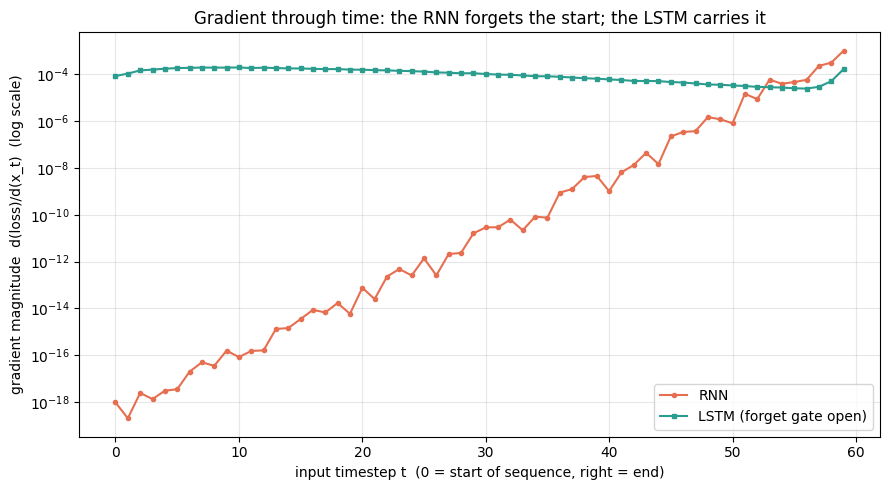

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(range(T), g_rnn,  "o-", label="RNN", color="#e76f51", markersize=3)
plt.plot(range(T), g_lstm, "s-", label="LSTM (forget gate open)", color="#2a9d8f", markersize=3)
plt.yscale("log")   # gradients span many orders of magnitude
plt.xlabel("input timestep t  (0 = start of sequence, right = end)")
plt.ylabel("gradient magnitude  d(loss)/d(x_t)  (log scale)")
plt.title("Gradient through time: the RNN forgets the start; the LSTM carries it")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## What you proved

**Symptom (Part 1):** on a task that requires remembering the first timestep, a plain RNN's accuracy
falls toward chance as the sequence lengthens, while the LSTM stays accurate. The plain RNN has a
short effective memory.

**Diagnosis (Part 2):** the plain RNN's gradient with respect to early timesteps collapses toward zero
- the output cannot depend on information that far back, because the learning signal never reaches it.
The LSTM's gated cell state keeps the gradient nearly flat across all timesteps, so it *can* learn
long-range dependencies. This is the Gradient Autopsy vanishing-gradient story, moved from the layer
axis to the time axis, and cured by gating instead of by ReLU/BatchNorm.

### Bridge to the rest of Group 3
LSTM (and its lighter cousin GRU) fix the memory problem. The next lab adds the two remaining pieces:
**bidirectional** RNNs (reading the sequence both ways for full context) and the **encoder-decoder**
pattern (sequence in, sequence out) - which ends by exposing the context-vector bottleneck that
attention will solve in Group 4.

### Try it yourself (optional)
- Add `"gru"` back into Part 1 and see how it compares (it uses the same gating idea; it can be more
  seed-sensitive on this exact task).
- In Part 2, change the LSTM `forget_bias` from 5.0 to 0.0 and re-plot - with the forget gate no longer
  forced open, the LSTM's gradient vanishes too, showing the forget gate is what does the work.

### Lab A · Concept check (interview-level)

**Q1. On the log-scale plot, the RNN's gradient decays in a nearly straight line toward early timesteps. Why exponential, specifically?**

Because backpropagation through time multiplies a Jacobian at every step. The gradient of the loss
with respect to an early input passes backward through one recurrence step per timestep, and each step
multiplies by (roughly) the same recurrent weight matrix and activation derivative. Repeated
multiplication by a similar factor is geometric: after k steps the gradient has been scaled by
approximately (that factor)^k. When the factor's magnitude is below 1 (which a contractive tanh
recurrence generally is), (factor)^k shrinks exponentially in k - a straight line on a log axis. The
sign of the exponent is set by the spectral radius of the recurrent Jacobian: below 1 gives vanishing,
above 1 gives exploding. The plain RNN has no mechanism to keep that factor near 1, so the decay is
baked into the architecture.

**Q2. Setting the LSTM forget-gate bias to 0 makes its gradient vanish too. What does that prove about where the LSTM's memory actually comes from?**

It proves the memory is not inherent to the LSTM architecture in the abstract - it comes specifically
from the forget gate being open. The cell state updates as C_t = f_t * C_{t-1} + i_t * candidate. The
gradient flowing back along the cell state is multiplied by the forget gate value f_t at each step.
When f_t is near 1 (forget bias high), that per-step factor is ~1, so the product across time stays
near 1 and the gradient is preserved - the "constant error carousel." When f_t is near 0.5 or lower
(forget bias 0, random gates), the cell state is multiplied by a sub-1 factor each step and the
gradient vanishes just like a plain RNN. So the LSTM's long-memory capability is a *learnable* property
contingent on the forget gate learning to stay open on the relevant information - not a guarantee. This
is also why initializing the forget bias high is a standard, effective trick.

**Q3. The gradient-through-time measurement used an untrained network. Isn't vanishing a property of learned weights - why is an untrained measurement valid?**

It is valid because vanishing/exploding gradients are primarily a property of the *architecture and
the scale of the recurrent map*, not of having trained. The exponential decay comes from repeated
multiplication by the recurrent Jacobian, whose magnitude is set at initialization and does not need
training to be below 1 - standard initializations produce a contractive map, so the decay is present
from step zero. Training can modestly change the spectral radius, but it cannot, for a plain RNN,
systematically hold it at exactly 1 across all directions and all inputs, which is what long-range
preservation would require. Measuring at init therefore isolates the architectural cause cleanly,
without conflating it with optimization effects - exactly the reason the measurement is so stark and
reproducible. (It is the same logic as measuring the per-layer vanishing gradient at initialization in
Gradient Autopsy.)